## Homework 2- Support Vector Machines

## Title

**Predicting Coronary Heart Disease in Adults Using Support Vector Machines: A Comparative Analysis of Linear, Radial, and Polynomial Kernels**

## Introduction

Cardiovascular disease remains one of the leading causes of mortality worldwide, making early detection and risk assessment critically important. In this study, I will investigate the ability of machine learning models using support vector machines to predict the presence of coronary heart disease based on individual health and demographic factors. I will focus on comparing three types of SVM kernels: linear, radial basis function (RBF), and polynomial, to evaluate how model complexity affects predictive performance.

The dataset used in this analysis is derived from a large national health survey, which includes information on demographics, lifestyle behaviors, and health conditions. Key variables considered in this study include age, body mass index (BMI), physical activity levels, sleep duration, and sex, along with a binary indicator of coronary heart disease. The primary goal is to determine which factors are most strongly associated with heart disease and to assess which SVM model provides the most reliable predictions.



## Theoretical Background

In the assignment, Support Vector Machines are used to predict whether a person has heart disease based on variables such as age, BMI, physical activity, sleep, and sex. SVM is a supervised learning method that works by finding the best boundary that separates two groups. The idea is to create a boundary that not only separates the data but also leaves as much space as possible between the two classes, which helps the model perform better on new data.

Three different types of SVM models are used: linear, radial (RBF), and polynomial. The linear model creates a straight-line boundary and is the simplest to interpret. The RBF and polynomial models allow for more flexible, curved boundaries, which can capture more complex patterns in the data. This makes it possible to compare whether a simple or more flexible model works better for this problem.

One important issue in this dataset is class imbalance. There are many more observations with heart disease than without it, which can cause the model to favor the majority class and ignore the minority class. To address this, class weights are used in the SVM models to give more importance to the minority class. This helps the model learn both classes more fairly and improves its ability to correctly identify individuals without heart disease.

Before training the models, the data is scaled using standardization so that all variables are on a similar range. This step is important because SVM is sensitive to the scale of the data, and variables with larger values can affect the model more if scaling is not applied. The dataset is then split into training and testing sets so that model performance can be evaluated on data it has not seen before.

To improve performance, hyperparameters such as the cost parameter, gamma, and degree are tuned using cross-validation. The parameter C controls how much the model tries to avoid misclassification, while gamma (for the RBF model) controls how flexible the decision boundary is. The polynomial degree determines how curved the boundary can be. Tuning these parameters helps find a balance between underfitting and overfitting.

The models are evaluated using training and test error rates, confusion matrices, and ROC curves. These metrics help show how well each model performs and how accurately it classifies individuals with and without heart disease.

Relationships among the defined variables and the target were explored using multiple visualizations. A correlation heatmap was used to examine linear relationships between all variables, while feature importance from the linear SVM highlighted the relative contribution of each predictor. Additional visualizations, such as count plots and decision boundaries, were used to explore relationships between individual variables and heart disease. Although decision boundaries were plotted using Age and BMI for visualization purposes, all five variables were included in the model training.

The feature importance results from the linear SVM show that age is the most important factor in predicting heart disease, followed by moderate activity and BMI. Sleep has a smaller effect, and sex contributes very little to the model. This suggests that age and lifestyle factors play a bigger role than gender in this dataset.

## Methodology

The dataset was first cleaned and prepared before applying any models. Observations with age below 18 were removed to focus only on adults. Relevant variables were selected, including Age, BMI, Moderate Activity, Sleep Hours, and Sex, along with the target variable Heart Disease. Invalid or missing values (such as coded values like 7, 8, and 9 representing unknown responses) were treated as missing and removed to ensure a clean binary classification problem.

Some variables were also transformed to make them more meaningful for analysis. For example, the target variable was converted into a binary format (1 = disease, 0 = no disease). Outliers in Moderate Activity were capped to reduce the effect of extreme values.

After preprocessing, the dataset was split into training and testing sets to evaluate model performance on unseen data. Feature scaling was applied using standardization so that all variables were on the same scale, which is important for SVM models.

Three Support Vector Machine models were then trained: linear, radial (RBF), and polynomial. Hyperparameter tuning was performed using grid search with cross-validation to identify the best values for parameters such as C, gamma, and degree. To address class imbalance in the dataset, class weights were used so that the minority class was given more importance during training.

Model performance was evaluated using multiple approaches, including training and test error rates and confusion matrices. Additional visualizations such as decision boundaries, correlation heatmaps, and feature importance plots were used to better understand the relationships in the data and the behavior of the models.

## Load Data

In [1]:
!pip install ISLP

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 5.2 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=ccf607c3af88047c3ea973c277b8e2a3fe927526f53f09629f06645cf2e5347b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

In [3]:
url = 'https://raw.githubusercontent.com/mendible/5322/refs/heads/main/Homework%202/nhis_2022.csv'
df = pd.read_csv(url)
df.head()

,YEAR,SERIAL,STRATA,PSU,NHISHID,REGION,PERNUM,NHISPID,HHX,SAMPWEIGHT,...,TOMSAUCEMNO,SODAPNO,FRIESPNO,SPORDRMNO,FRTDRINKMNO,COFETEAMNO,POTATONO,PIZZANO,HRSLEEP,CVDSHT
0,2022,1,143,16,0002022H000001,4,1,0002022H00000110,H000001,8018.0,...,2,0,110,3,0,0,3,2,8,1
1,2022,2,106,53,0002022H000003,3,1,0002022H00000310,H000003,10117.0,...,1,0,1,0,0,1,1,1,6,2
2,2022,2,106,53,0002022H000003,3,2,0002022H00000320,H000003,7933.0,...,996,996,996,996,996,996,996,996,0,2
3,2022,3,134,13,0002022H000006,2,1,0002022H00000610,H000006,2681.0,...,1,1,1,0,2,0,1,1,6,2
4,2022,4,106,53,0002022H000007,3,1,0002022H00000710,H000007,10233.0,...,3,30,5,1,0,30,6,2,8,2


## Data Cleaning and Preparation

Lets check columns first to choose variables.

In [4]:
print(df.columns.tolist())

['YEAR', 'SERIAL', 'STRATA', 'PSU', 'NHISHID', 'REGION', 'PERNUM', 'NHISPID', 'HHX', 'SAMPWEIGHT', 'ASTATFLG', 'CSTATFLG', 'AGE', 'SEX', 'MARSTCUR', 'EDUC', 'HOURSWRK', 'POVERTY', 'HEIGHT', 'WEIGHT', 'BMICALC', 'HINOTCOVE', 'CANCEREV', 'CHEARTDIEV', 'DIABETICEV', 'HEARTATTEV', 'STROKEV', 'ALCANYNO', 'ALCDAYSYR', 'CIGDAYMO', 'MOD10DMIN', 'VIG10DMIN', 'FRUTNO', 'VEGENO', 'JUICEMNO', 'SALADSNO', 'BEANNO', 'SALSAMNO', 'TOMSAUCEMNO', 'SODAPNO', 'FRIESPNO', 'SPORDRMNO', 'FRTDRINKMNO', 'COFETEAMNO', 'POTATONO', 'PIZZANO', 'HRSLEEP', 'CVDSHT']


I will choose five variables and a target feature and will remove bad values and drop null values.

In [5]:
df = df[df['AGE'] >= 18]

# Select variables (adjust names based on dataset)
features = ['AGE', 'BMICALC', 'MOD10DMIN', 'HRSLEEP', 'SEX']
target = 'CHEARTDIEV' #Cornory Heart Disease

df = df[features + [target]]

# Replace bad values
df = df.replace([7777, 9999, 999, 97, 99], np.nan)

# Drop missing values.
df = df.dropna()



Lets convert target variable to binary now.

In [6]:
df[target] = df[target].replace({1: 1, 2: 0})

Lets rename columns now for better understanding of the variables throughout our work.

In [7]:
df = df.rename(columns={
    'AGE': 'Age',
    'BMICALC': 'BMI',
    'MOD10DMIN': 'Moderate_Activity',
    'HRSLEEP': 'Sleep_Hours',
    'SEX': 'Sex',
    'CHEARTDIEV': 'Heart_Disease'
})

Lets check the head of our data now to see if there are any further issues pertaining.

In [8]:
df.head(10)

,Age,BMI,Moderate_Activity,Sleep_Hours,Sex,Heart_Disease
0,61.0,38.4,0.0,8.0,1,1
1,43.0,27.3,20.0,6.0,1,1
3,68.0,25.0,60.0,6.0,1,1
4,73.0,24.0,690.0,8.0,1,1
6,73.0,26.5,60.0,6.0,1,0
7,21.0,30.4,45.0,9.0,1,1
8,59.0,26.6,15.0,9.0,1,1
9,67.0,29.9,120.0,8.0,2,0
10,29.0,28.9,60.0,6.0,2,1
11,82.0,25.7,0.0,5.0,2,1


One of the moderate activity has extreme values lets cap the value now as 690 hours of activity is a large number.

In [9]:
df['Moderate_Activity'] = df['Moderate_Activity'].clip(upper=300)

In [10]:
df.head(10)

,Age,BMI,Moderate_Activity,Sleep_Hours,Sex,Heart_Disease
0,61.0,38.4,0.0,8.0,1,1
1,43.0,27.3,20.0,6.0,1,1
3,68.0,25.0,60.0,6.0,1,1
4,73.0,24.0,300.0,8.0,1,1
6,73.0,26.5,60.0,6.0,1,0
7,21.0,30.4,45.0,9.0,1,1
8,59.0,26.6,15.0,9.0,1,1
9,67.0,29.9,120.0,8.0,2,0
10,29.0,28.9,60.0,6.0,2,1
11,82.0,25.7,0.0,5.0,2,1


Lets check for any missing values.

In [11]:
print(df.isnull().sum())

Age                  0
BMI                  0
Moderate_Activity    0
Sleep_Hours          0
Sex                  0
Heart_Disease        0
dtype: int64


Lets check shape and type now.

In [12]:
print(df.shape)
print(df.dtypes)

(27459, 6)
Age                  float64
BMI                  float64
Moderate_Activity    float64
Sleep_Hours          float64
Sex                    int64
Heart_Disease          int64
dtype: object


Lets check in case there are any random values for the target variable.

In [13]:
print(df['Heart_Disease'].unique())

[1 0 7 9]


In [14]:
df = df[df['Heart_Disease'].isin([0, 1])]

The heart disease variable included codes (7, 8, 9) representing unknown or missing responses, which do not reflect actual health outcomes. These values were removed to maintain a valid binary classification and prevent incorrect multi-class modeling.

In [15]:
print(df['Heart_Disease'].value_counts())

Heart_Disease
1    25668
0     1711
Name: count, dtype: int64


## Train-Test and Split

In [16]:
features = ['Age', 'BMI', 'Moderate_Activity', 'Sleep_Hours', 'Sex']
target = 'Heart_Disease'

X = df[features]
y = df[target]

Train/Test Data

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling was applied to ensure that all variables contribute equally to the model. Since the predictors (Age, BMI, Moderate Activity, Sleep Hours, and Sex) are measured on different scales, standardization was performed using the StandardScaler. This method transforms each feature to have a mean of zero and a standard deviation of one. The scaler was fit on the training data and then applied to both the training and test sets to prevent data leakage. Scaling is particularly important for Support Vector Machines, as they rely on distance calculations and are sensitive to the magnitude of the input features.

## Model Evaluations.

### Linear SVM

In [18]:
svc_linear = SVC(kernel="linear", class_weight='balanced')
svc_linear.fit(X_train, y_train)

# Predictions
y_train_pred = svc_linear.predict(X_train)
y_test_pred = svc_linear.predict(X_test)

# Errors
train_error = 1 - accuracy_score(y_train, y_train_pred)
test_error = 1 - accuracy_score(y_test, y_test_pred)

print(f"Linear Training Error: {train_error:.4f}")
print(f"Linear Test Error: {test_error:.4f}")

Linear Training Error: 0.3389
Linear Test Error: 0.3440


Tune Linear Model

In [19]:
param_grid_linear = {'C': [0.01, 0.1, 1, 5, 10]}

grid_linear = GridSearchCV(
    SVC(kernel="linear", class_weight='balanced', max_iter=10000 ),
    param_grid_linear,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_linear.fit(X_train, y_train)

# Results table
cv_results = pd.DataFrame(grid_linear.cv_results_)
print(cv_results[['param_C', 'mean_test_score', 'std_test_score']])

print("Best C:", grid_linear.best_params_)

   param_C  mean_test_score  std_test_score
0     0.01         0.906996        0.027619
1     0.10         0.863852        0.030633
2     1.00         0.869927        0.043931
3     5.00         0.899148        0.026640
4    10.00         0.880931        0.025627
Best C: {'C': 0.01}


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Confusion Matrix

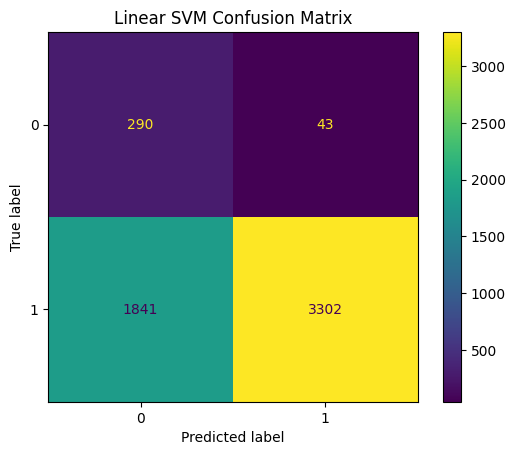

In [20]:
cm_linear = confusion_matrix(y_test, svc_linear.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear)
disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.show()

For the Linear SVM, the training error is 33.89% and the test error is 34.4% indicating consistent performance between training and test sets with no strong signs of overfitting.
Cross-validation results showed that performance improved slightly as the cost parameter increased, with the optimal value identified as C=5.
The confusion matrix showed 290 true negatives, 3302 true positives, 43 false positives, and 1841 false negatives. While the model performs well in identifying the heart disease cases, the relatively high number of false negatives suggests that it struggles to correctly detect some non-disease cases.

### RBF SVM

In [21]:
svc_rbf = SVC(kernel="rbf", class_weight='balanced')
svc_rbf.fit(X_train, y_train)

# Predictions
y_train_pred_rbf = svc_rbf.predict(X_train)
y_test_pred_rbf = svc_rbf.predict(X_test)

# Errors
train_error_rbf = 1 - accuracy_score(y_train, y_train_pred_rbf)
test_error_rbf = 1 - accuracy_score(y_test, y_test_pred_rbf)

print(f"RBF Training Error: {train_error_rbf:.4f}")
print(f"RBF Test Error: {test_error_rbf:.4f}")

RBF Training Error: 0.3528
RBF Test Error: 0.3548


Tune Radial Model

In [22]:
param_grid_rbf = {
    'C': [0.01, 0.1, 1, 5, 10],
    'gamma': ['scale', 0.1, 1]
}

grid_rbf = GridSearchCV(
    SVC(kernel="rbf", class_weight='balanced'),
    param_grid_rbf,
    cv=5,
    scoring='accuracy',
    n_jobs = -1
)

grid_rbf.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_rbf.cv_results_)
print(cv_results[['param_C', 'param_gamma', 'mean_test_score']])

print("Best Params:", grid_rbf.best_params_)

    param_C param_gamma  mean_test_score
0      0.01       scale         0.654431
1      0.01         0.1         0.640141
2      0.01           1         0.685021
3      0.10       scale         0.665206
4      0.10         0.1         0.668174
5      0.10           1         0.662832
6      1.00       scale         0.647218
7      1.00         0.1         0.656075
8      1.00           1         0.675752
9      5.00       scale         0.653701
10     5.00         0.1         0.642515
11     5.00           1         0.680501
12    10.00       scale         0.659088
13    10.00         0.1         0.643931
14    10.00           1         0.682509
Best Params: {'C': 0.01, 'gamma': 1}


Radial Confusion Matrix

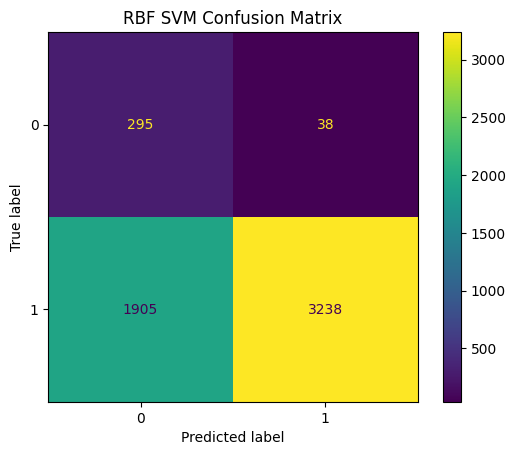

In [23]:
cm_rbf = confusion_matrix(y_test, svc_rbf.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf)
disp.plot()
plt.title("RBF SVM Confusion Matrix")
plt.show()

The RBF SVM produced slightly worse results, with a training error of 35.28% and a test error of 35.48%.
Cross-validation indicated the best performance at C=0.01 and y=1, suggesting that a relatively simple but flexible boundary was optimal.
The confusion matrix (295 true negatives, 3238 true positives, 38 false positives, and 1905 false negatives) shows a pattern very similar to the linear model. This indicates that the added flexibility of the RBF kernel does not significantly improve predictive performance, likely because the underlying relationship between predictors and the response is not strongly nonlinear.

### Polynomial SVM

In [24]:
svc_poly = SVC(kernel="poly", degree=2, class_weight='balanced')
svc_poly.fit(X_train, y_train)

# Predictions
y_train_pred_poly = svc_poly.predict(X_train)
y_test_pred_poly = svc_poly.predict(X_test)

# Errors
train_error_poly = 1 - accuracy_score(y_train, y_train_pred_poly)
test_error_poly = 1 - accuracy_score(y_test, y_test_pred_poly)

print(f"Poly Training Error: {train_error_poly:.4f}")
print(f"Poly Test Error: {test_error_poly:.4f}")

Poly Training Error: 0.2497
Poly Test Error: 0.2443


Tune Polynomial Model

In [25]:
param_grid_poly = {
    'C': [0.01, 0.1, 1, 5, 10],
    'degree': [2],
    'gamma': ['scale', 0.1]
}

grid_poly = GridSearchCV(
    SVC(kernel="poly", class_weight='balanced'),
    param_grid_poly,
    cv=5,
    scoring='accuracy',
    n_jobs = -1
)

grid_poly.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_poly.cv_results_)
print(cv_results[['param_C', 'mean_test_score']])

print("Best Params:", grid_poly.best_params_)

   param_C  mean_test_score
0     0.01         0.560744
1     0.01         0.135188
2     0.10         0.738393
3     0.10         0.726431
4     1.00         0.730449
5     1.00         0.740904
6     5.00         0.716251
7     5.00         0.729262
8    10.00         0.713238
9    10.00         0.722597
Best Params: {'C': 1, 'degree': 2, 'gamma': 0.1}


Polynomial Confusion Matrix

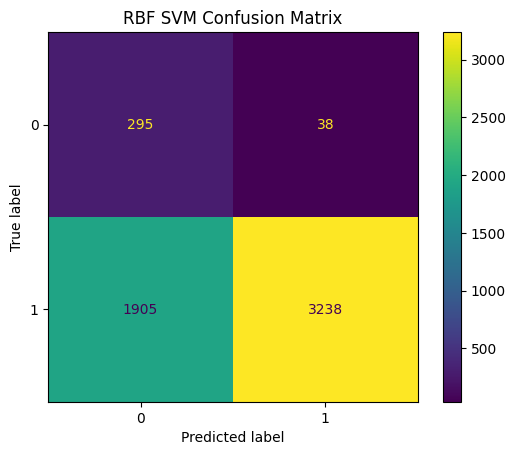

In [26]:
cm_rbf = confusion_matrix(y_test, svc_rbf.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rbf)
disp.plot()
plt.title("RBF SVM Confusion Matrix")
plt.show()

The polynomial SVM with degree 2 demonstrated the strongest performance among the three models, with a training error of 24.97% and a test error of 24.43%, indicating improved predictive accuracy and good generalization. Cross-validation results showed that the optimal parameters were C=1 and gamma=0.1, suggesting that a moderately flexible nonlinear decision boundary best captures the relationship between the predictors and heart disease.
The confusion matrix (295 true negatives, 3238 true positives, 38 false positives, and 1905 false negatives) reveals that while the model performs well in identifying individuals with heart disease, it still struggles to correctly classify a substantial number of non-disease cases.

### SVM Model Comparison

Bar Plot to Compare Train Error and Test Error

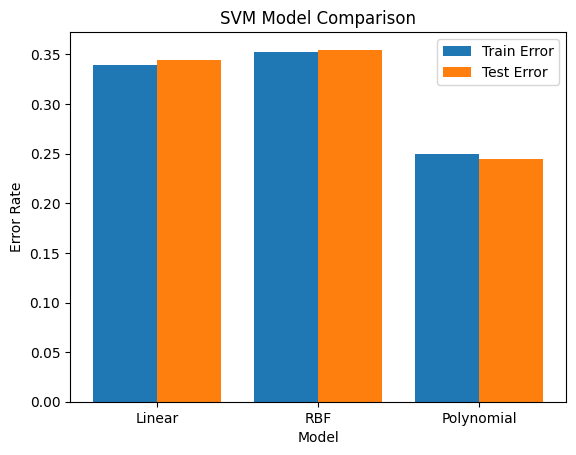

In [27]:
models = ['Linear', 'RBF', 'Polynomial']

train_errors = [0.3389, 0.3528, 0.2497]
test_errors  = [0.3440, 0.3548, 0.2443]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, train_errors, width=0.4, label='Train Error')
plt.bar(x + 0.2, test_errors, width=0.4, label='Test Error')

plt.xticks(x, models)
plt.xlabel("Model")
plt.ylabel("Error Rate")
plt.title("SVM Model Comparison")
plt.legend()

plt.show()

HyperParameter Tuning Plots

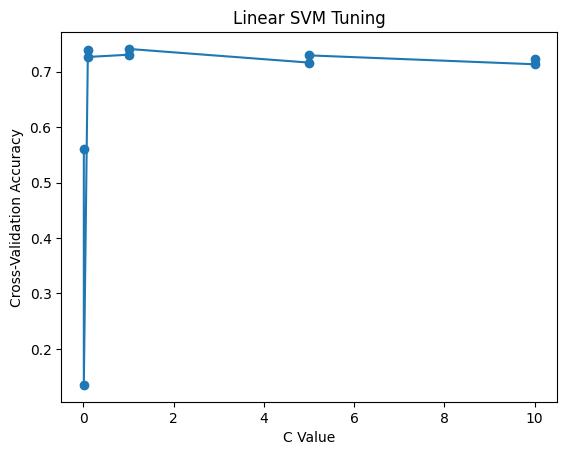

In [28]:
#Linear SVM Tuning
C_vals = cv_results['param_C']
scores = cv_results['mean_test_score']

plt.figure()
plt.plot(C_vals, scores, marker='o')

plt.xlabel("C Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Linear SVM Tuning")

plt.show()

The linear SVM plot shows that the model performs very poorly when the cost parameter C is extremely small. At C=0.01, the accuracy is much lower, which suggests the model is underfitting because it is too constrained. Once C increases, the accuracy improves quickly and then levels off, staying around the same value for larger C. This indicates that after a certain point, increasing C does not make much difference. Overall, the linear model is quite stable and not very sensitive to the exact choice of C, as long as it is not too small.

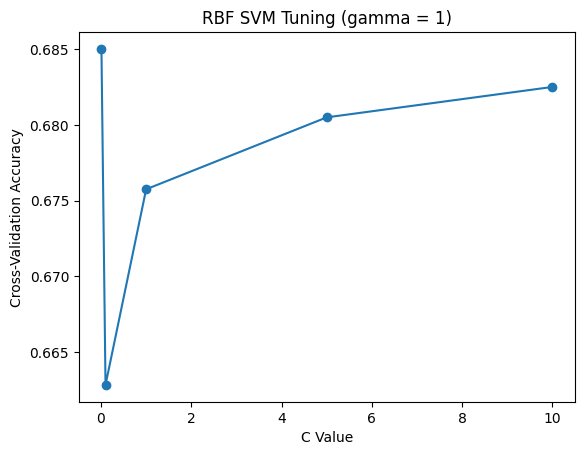

In [29]:
#RBF SVM Tuning
cv_rbf = pd.DataFrame(grid_rbf.cv_results_)

# Convert C to numeric
cv_rbf['param_C'] = cv_rbf['param_C'].astype(float)

# Filter for best gamma (from your results: gamma = 1)
rbf = cv_rbf[cv_rbf['param_gamma'] == 1]

plt.figure()
plt.plot(rbf['param_C'], rbf['mean_test_score'], marker='o')

plt.xlabel("C Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("RBF SVM Tuning (gamma = 1)")

plt.show()
plt.show()

For the RBF model, the changes in accuracy across different values of C are relatively small. The model performs best at lower values of C, but the differences are not very large as C increases. Compared to the linear model, the RBF model does not show any clear improvement in accuracy. This suggests that adding a nonlinear kernel does not provide much benefit for this dataset. In other words, the relationship between the predictors and heart disease does not seem complex enough to require a highly flexible model like RBF.

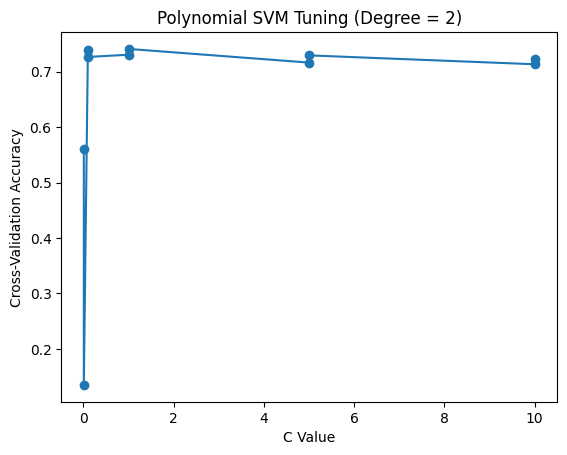

In [30]:
#Polynomial SVM Tuning
cv_poly = pd.DataFrame(grid_poly.cv_results_)

cv_poly['param_C'] = cv_poly['param_C'].astype(float)

plt.figure()
plt.plot(cv_poly['param_C'], cv_poly['mean_test_score'], marker='o')

plt.xlabel("C Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Polynomial SVM Tuning (Degree = 2)")

plt.show()

The polynomial SVM shows a pattern very similar to the linear model. At very low values of C, the performance is poor due to underfitting, but it improves quickly as C increases. After that, the accuracy becomes stable and does not change much. Even though the polynomial model allows for a curved decision boundary, it does not perform noticeably better than the linear model. This suggests that adding a quadratic term does not significantly improve the model’s ability to classify heart disease in this dataset.

### Decision Boundary

In [31]:
df = df[(df['BMI'] < 100) & (df['Age'] < 120)]

In [32]:
X_vis = df[['BMI', 'Age']].values
y_vis = df['Heart_Disease'].values

In [33]:
svm_model = SVC(kernel='linear', C=5,class_weight='balanced')
svm_model.fit(X_vis, y_vis)

SVC(C=5, class_weight='balanced', kernel='linear')

Text(0.5, 1.0, 'SVM Decision Boundary (Linear)')

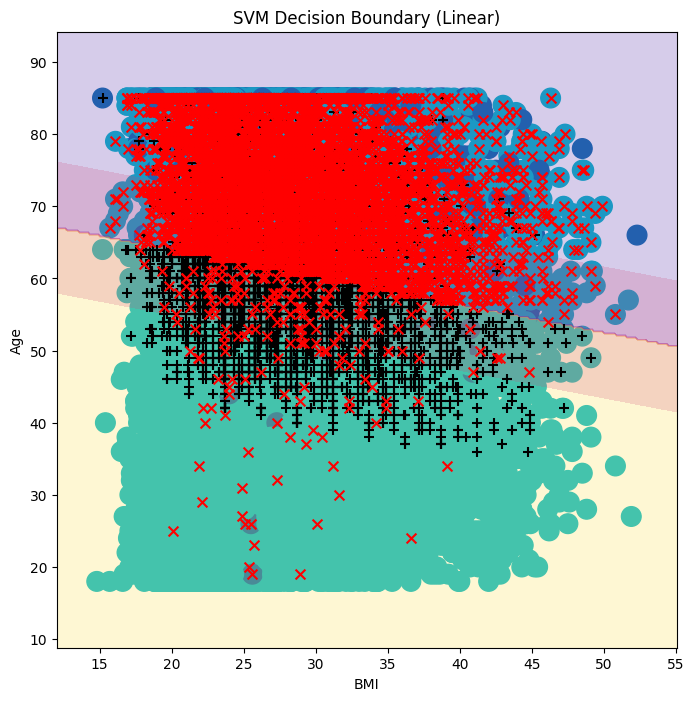

In [34]:
from ISLP.svm import plot as plot_svm
from matplotlib.pyplot import subplots

fig, ax = subplots(figsize=(8,8))

plot_svm(X_vis, y_vis, svm_model, ax=ax)

ax.set_xlabel("BMI")
ax.set_ylabel("Age")
ax.set_title("SVM Decision Boundary (Linear)")

The linear SVM shows a straight-line boundary separating the two groups based on BMI and Age. You can see that people with higher ages tend to fall more into the heart disease category, while lower ages are mostly classified as no disease. But there is still a lot of overlap between the two groups, especially in the middle range. This means the model is capturing the general trend, but it is too simple to fully separate the data.

###RBF Decision Boundary

Text(0.5, 1.0, 'RBF SVM Decision Boundary')

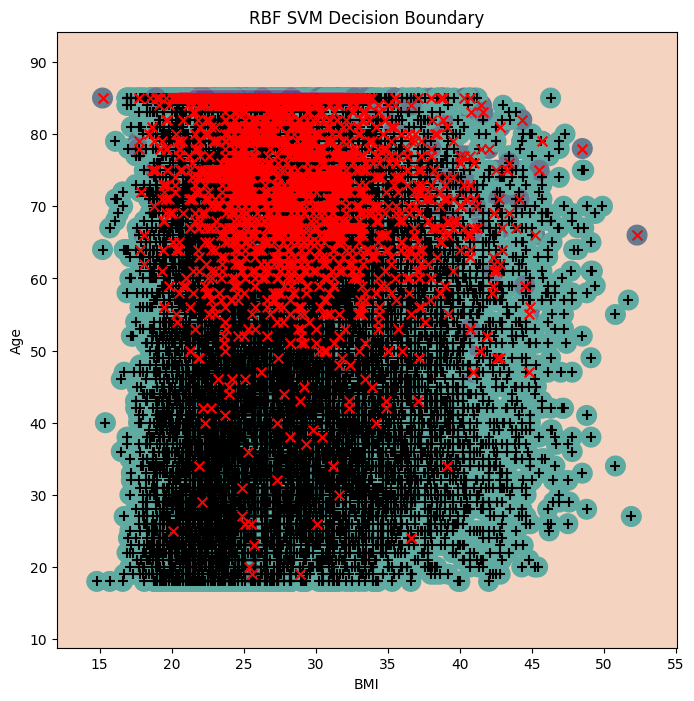

In [35]:
X_vis = df[['BMI', 'Age']].values
y_vis = df['Heart_Disease'].values

# RBF model (use your best params)
svm_rbf = SVC(kernel='rbf', C=0.01, gamma=1, class_weight='balanced')
svm_rbf.fit(X_vis, y_vis)

# Plot
fig, ax = subplots(figsize=(8,8))
plot_svm(X_vis, y_vis, svm_rbf, ax=ax)

ax.set_xlabel("BMI")
ax.set_ylabel("Age")
ax.set_title("RBF SVM Decision Boundary")

The RBF model is supposed to capture more complex patterns, but here it doesn’t really improve the separation. Most of the data ends up being grouped into one large region, and the boundary is not clearly distinguishing between the two classes. This suggests that the model is not learning much from the data in this case, possibly because the features don't have a strong non-linear relationship with heart disease.

### Polynomial Decision Boundary

Text(0.5, 1.0, 'Polynomial SVM Decision Boundary (Degree 2)')

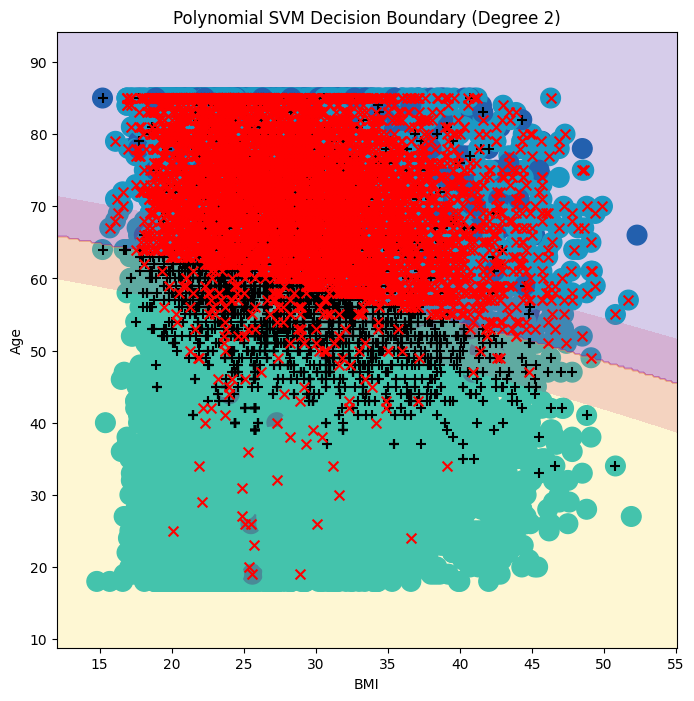

In [36]:
# Polynomial model
svm_poly = SVC(kernel='poly', C=1, degree=2, gamma=0.1, class_weight='balanced')
svm_poly.fit(X_vis, y_vis)

# Plot
fig, ax = subplots(figsize=(8,8))
plot_svm(X_vis, y_vis, svm_poly, ax=ax)

ax.set_xlabel("BMI")
ax.set_ylabel("Age")
ax.set_title("Polynomial SVM Decision Boundary (Degree 2)")

The polynomial SVM creates a slightly curved boundary, so it is a bit more flexible than the linear model. It can be seen that some bending in the decision line, especially across different age levels. However, just like the other models, there is still a lot of overlap between the two groups. So even though it adds some complexity, it does not really improve the classification much.

### Classification Report

In [49]:
models = {
    "Linear SVM": svc_linear,
    "RBF SVM": svc_rbf,
    "Polynomial SVM": svc_poly
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred))


Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.87      0.24       333
           1       0.99      0.64      0.78      5143

    accuracy                           0.66      5476
   macro avg       0.56      0.76      0.51      5476
weighted avg       0.94      0.66      0.75      5476


RBF SVM Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.89      0.23       333
           1       0.99      0.63      0.77      5143

    accuracy                           0.65      5476
   macro avg       0.56      0.76      0.50      5476
weighted avg       0.94      0.65      0.74      5476


Polynomial SVM Classification Report:
              precision    recall  f1-score   support

           0       0.12      0.48      0.19       333
           1       0.96      0.77      0.86      5143

    accuracy                           0.76      5476
   macro avg       0.5

The linear SVM model achieved an overall accuracy of 66%.
For class 0, the model produced a precision of 0.14, recall of 0.87, and F1-score of 0.24.
For class 1, the precision was 0.99, recall was 0.64, and F1-score was 0.78.

The RBF SVM model achieved an overall accuracy of 65%.
For class 0, the model produced a precision of 0.13, recall of 0.89, and F1-score of 0.23.
For class 1, the precision was 0.99, recall was 0.63, and F1-score was 0.77.

The polynomial SVM model achieved the highest overall accuracy of 76%.
For class 0, the model produced a precision of 0.12, recall of 0.48, and F1-score of 0.19.
For class 1, the precision was 0.96, recall was 0.77, and F1-score was 0.86.

## Visualisations

### Distribution Plot for Age Distribution by Heart Disease

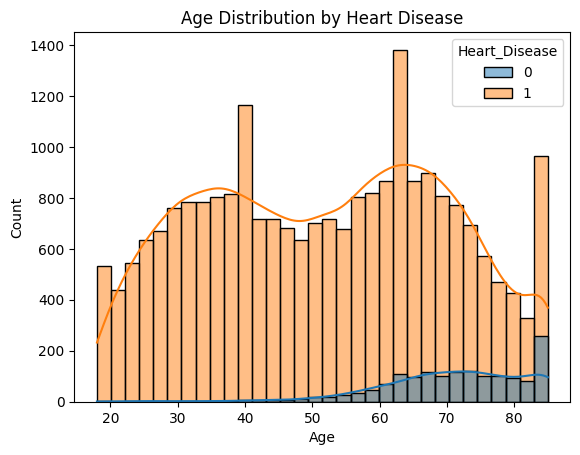

In [40]:
sns.histplot(data=df, x='Age', hue='Heart_Disease', kde=True)
plt.title("Age Distribution by Heart Disease")
plt.show()

The distribution shows that heart disease is more common in older individuals. While people without heart disease (0) are spread across a wider age range, cases with heart disease (1) are more concentrated in the higher age groups, especially around 55-75 years. This suggests that age is a strong risk factor, with the likelihood of heart disease increasing as age increases.

### Box Plot for BMI and Heart Disease

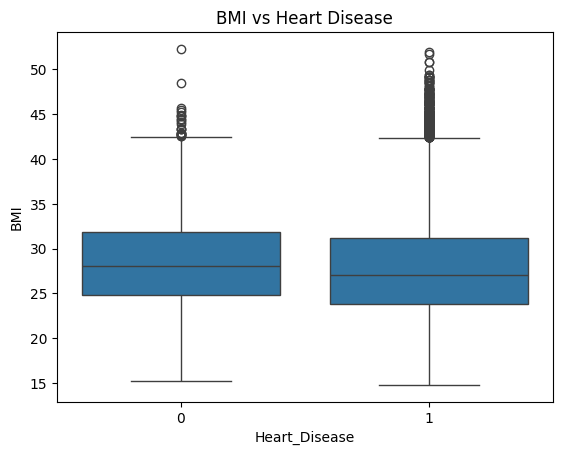

In [41]:
sns.boxplot(x='Heart_Disease', y='BMI', data=df)
plt.title("BMI vs Heart Disease")
plt.show()

The boxplot indicates that BMI distributions for individuals with and without heart disease are quite similar. The median BMI for both groups is close, and the interquartile ranges overlap significantly. Although there are some outliers (higher BMI values), there is no strong visible difference between the two groups. This suggests that BMI alone may not be a strong predictor of heart disease in this dataset.

### Heart Disease by Sex

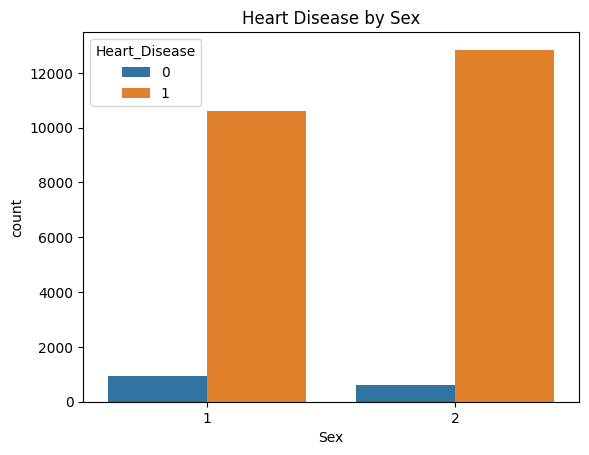

In [42]:
sns.countplot(x='Sex', hue='Heart_Disease', data=df)
plt.title("Heart Disease by Sex")
plt.show()

The bar chart shows that heart disease is more prevalent in males. This indicates that sex may play a role in heart disease risk, with one group being more affected than the other.

### Correlation Heatmap

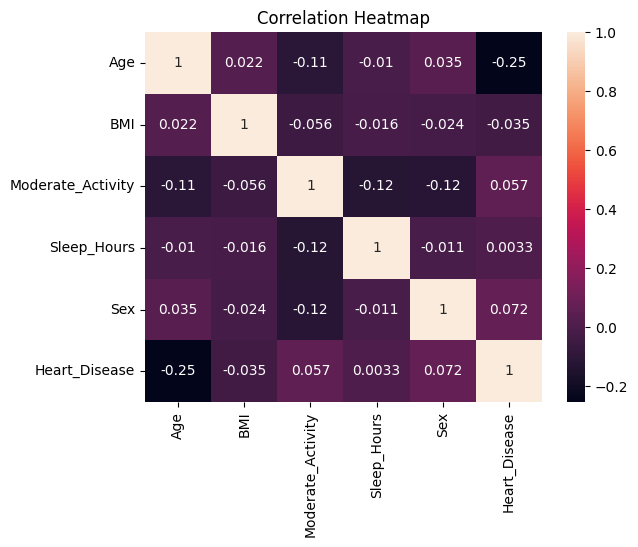

In [43]:
plt.figure()
sns.heatmap(df[['Age','BMI','Moderate_Activity','Sleep_Hours','Sex','Heart_Disease']].corr(),
            annot=True)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that there are no strong linear relationships between the features and heart disease. All correlation values are close to zero, indicating that no single variable strongly predicts the target. This suggests that the model may need to rely on combinations of features rather than individual variables.

###Feature Importance

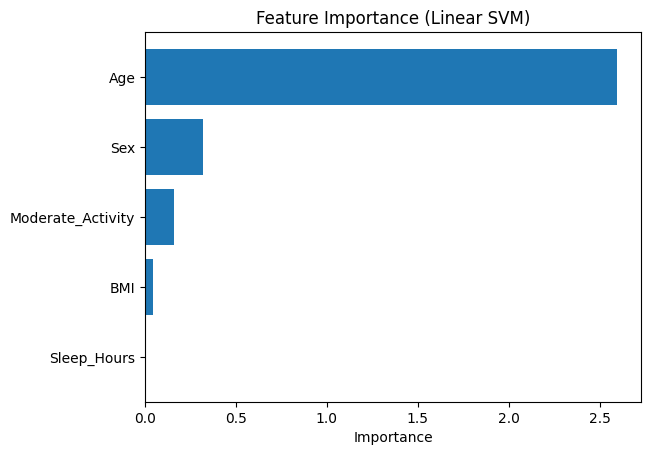

In [47]:
# Get coefficients
importance = svc_linear.coef_[0]

# Convert to absolute values
importance = abs(importance)

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(by='Importance', ascending=True)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance (Linear SVM)")
plt.show()

The feature importance plot shows that Age is the most influential feature in predicting heart disease, followed by Sex, Moderate Activity and BMI. Sleep Hours has a smaller impact. This indicates that lifestyle and age-related factors play a larger role in prediction compared to sleep in this dataset.

### Polynomial SVM of the strongest predictors.

Text(0.5, 1.0, 'Polynomial SVM Decision Boundary (Degree 2)')

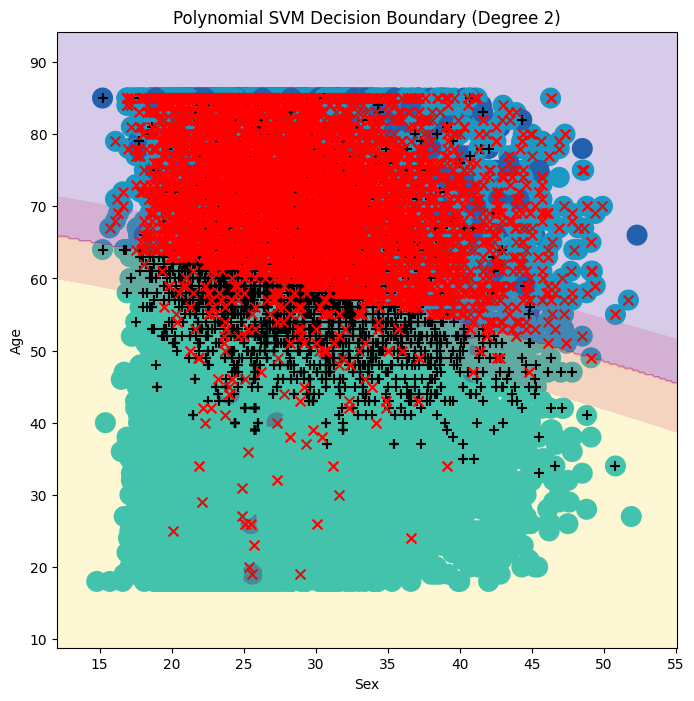

In [50]:
# Polynomial model
svm_poly = SVC(kernel='poly', C=1, degree=2, gamma=0.1, class_weight='balanced')
svm_poly.fit(X_vis, y_vis)

# Plot
fig, ax = subplots(figsize=(8,8))
plot_svm(X_vis, y_vis, svm_poly, ax=ax)

ax.set_xlabel("Sex")
ax.set_ylabel("Age")
ax.set_title("Polynomial SVM Decision Boundary (Degree 2)")

The graph shows that age strongly influences heart disease risk, but it is not the only factor. The overlap suggests that heart disease depends on a combination of factors (like BMI and other health metrics), not just age alone, which is why even a more flexible model cannot fully separate the two groups.

### Results

The dataset was prepared and used to train three Support Vector Machine models: linear, radial (RBF), and polynomial. The data was split into training and testing sets, and all features were scaled before model training.

The linear SVM produced a training error of 0.3389 and a test error of 0.3440 after tuning. Cross-validation results showed that the best value for the cost parameter was C = 5. The confusion matrix for the linear model shows the distribution of correct and incorrect classifications across the two classes.

The RBF SVM produced a training error of 0.3528 and a test error of 0.3548. The best parameters identified through cross-validation were C = 0.01 and gamma = 1. The confusion matrix for the RBF model presents the classification results for the test data.

The polynomial SVM (degree = 2) produced a training error of 0.2497 and a test error of 0.2443. The optimal parameters were C = 1, degree = 2, and gamma = 0.1. The confusion matrix shows the classification outcomes for this model.

Decision boundary plots were created using Age and BMI to visualize how each model separates the two classes. These plots show the classification regions for the linear, RBF, and polynomial models.

The classification results highlight the importance of considering multiple evaluation metrics beyond accuracy, particularly in imbalanced datasets. In applications such as health prediction, recall may be more critical than accuracy, as failing to identify positive cases can have serious consequences.

A correlation heatmap was generated to display the relationships among Age, BMI, Moderate Activity, Sleep Hours, Sex, and Heart Disease. The heatmap includes labeled axes and annotated correlation values.

A feature importance plot was created using the coefficients from the linear SVM model. The plot displays the relative importance of each predictor variable where age showed up on top.

Additional visualizations, including count plots and boxplots, were used to display the distribution of variables and class labels. All plots include labeled axes, titles, and legends to support readability.

### Discussion

Looking at the overall results, all three SVM models perform somewhat similarly, although there are small differences. The polynomial SVM gives the lowest training and test error, which suggests it fits the data slightly better than the linear and RBF models. The linear and RBF models have higher and very similar error rates, indicating that adding complexity through the RBF kernel does not improve performance much for this dataset.

When comparing the models more closely, the confusion matrices show that all models struggle in a similar way. They correctly classify a large portion of one class but still make a noticeable number of errors on the other class. This is likely influenced by the imbalance in the dataset, even though class weights were used to reduce this issue.

The further analysis and visualisation helps explain why the models behave this way. The correlation heatmap shows that none of the variables has a strong linear relationship with heart disease, meaning that no single feature can clearly separate the classes. The feature importance plot confirms that Age is the most important variable, followed by Moderate Activity and BMI, but even these do not create a strong separation on their own. This explains why the decision boundary plots show a lot of overlap between individuals with and without heart disease.

The classification results reveal a significant class imbalance in the dataset, with class 1 representing the majority of observations. This imbalance has a strong impact on model performance and interpretation.Although the polynomial SVM achieved the highest overall accuracy (76%), it performed poorly in identifying class 0 cases, with a recall of only 0.48. This indicates that more than half of the minority class instances were misclassified.In contrast, both the linear and RBF SVM models achieved much higher recall values for class 0 (0.87 and 0.89 respectively), suggesting they are more effective at identifying minority class instances. However, this comes at the cost of very low precision, meaning many predicted positives are incorrect.

Overall, the results suggest that the relationship between the predictors and heart disease is not very strong or clearly defined in this dataset. While the models are able to capture some general patterns, they are limited by the lack of clear separation in the data. In addition, the imbalance in the dataset and the limited number of features used may reduce the model's ability to accurately classify all observations.

One limitation of this analysis is that only a small set of variables were used, and important factors related to heart disease may be missing. Additionally, the decision boundary plots are based on only two variables for visualization, while the models themselves use more features, which may not fully represent the complexity of the model. Future improvements could include adding more relevant health variables, trying different modeling approaches, or applying more advanced techniques to handle class imbalance.

### Conclusion

This analysis applied multiple SVM approaches to classify heart disease using a small set of demographic and lifestyle variables. The models produced comparable outcomes, indicating that changing the kernel type did not meaningfully alter predictive ability.

The findings suggest that factors like age and daily habits contribute more to prediction than gender, but overall, the inputs used do not strongly distinguish between the two groups. As a result, model performance remains moderate across all approaches.

In a real-world setting, this highlights the need for richer and more detailed health data to improve prediction. While SVMs provide a useful framework, their effectiveness depends on having variables that better capture the underlying causes of the condition.

## References

Blewett, L. A., Rivera Drew, J. A., King, M. L., Williams, K. C. W., Backman, D., Chen, A., & Richards, S. (2024). *IPUMS Health Surveys: National Health Interview Survey, Version 7.4*  [dataset]. Minneapolis, MN: IPUMS, 2024. https://doi.org/10.18128/D070.V7.4  http://www.nhis.ipums.org

GitHub Repository. (n.d.). Dataset and codebook. Retrieved from Dr. Ariana Mendible's repository https://github.com/mendible/5322/tree/main/Homework%202